🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Pipeline (B)** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb) → [05 Suggest engine](../pipeline/05_suggest_engine.ipynb) · [07 Run week + report](../pipeline/07_run_week_and_report.ipynb)
**Tutorials (A)** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics (C)** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb)
**Neural + LLM (D)** · [08 NN (educational)](../neural/08_neural_surrogates_edu.ipynb) · [09 NN for F6](../neural/09_neural_surrogates_F6.ipynb) · [10 NN engine](../neural/10_neural_surrogates_engine.ipynb)

> 📍 **This notebook** — **Tutorial 1 (A · educational, not in the weekly loop). Gaussian-process theory from first principles: priors, posteriors, kernels.**

---

# 🎯 Gaussian Process & Bayesian Optimization: A Learning Journey

**Author:** Capstone Project — Black Box Challenge  
**Purpose:** Learn GP concepts from scratch, connecting theory to Python code

---

> **How to use this notebook:** Each section builds on the last. Read the theory, then *run* the code and *see* the connection. The goal is not just to understand the code — it's to *feel* what's happening mathematically.

---

# PART 0: Loading the Black Box Data

Before we dive into theory, let's load the 8 black-box functions we need to optimize.  
This comes directly from your `load_npy_data` notebook.

In [1]:
import os
"""
SECTION 0 — Load initial data for all 8 black-box functions.

Folder structure expected:
    initial_data/
        function_1/  initial_inputs.npy   initial_outputs.npy
        function_2/  ...
        ...
        function_8/  ...
"""

import numpy as np
from pathlib import Path

# ── CONFIGURE THIS PATH to match your setup ────────────────────
ROOT_DIR = os.environ.get("BBO_INITIAL_DATA", "data/initial_data")
# ───────────────────────────────────────────────────────────────

def load_all_data(root_dir: str) -> dict:
    """Load initial_inputs.npy and initial_outputs.npy from each function_N subdirectory."""
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Root directory not found:\n  {root}")
    
    data = {}
    subdirs = sorted(
        [p for p in root.iterdir() if p.is_dir() and p.name.startswith("function_")],
        key=lambda p: int(p.name.split("_")[1])
    )
    
    print(f"Found {len(subdirs)} subdirectories in:\n  {root}\n")
    for subdir in subdirs:
        print(f"  Loading [{subdir.name}] ...")
        entry = {}
        for label, filename in [("input", "initial_inputs.npy"), ("output", "initial_outputs.npy")]:
            path = subdir / filename
            if path.exists():
                entry[label] = np.load(path, allow_pickle=True)
                print(f"    ✔ {filename:25s}  shape={entry[label].shape}  dtype={entry[label].dtype}")
            else:
                print(f"    ✘ {filename} — FILE NOT FOUND")
        if entry:
            data[subdir.name] = entry
    return data


def summarise(data: dict) -> None:
    print(f"\n{'='*60}")
    print(f" SUMMARY — {len(data)} directories loaded")
    print(f"{'='*60}")
    print(f"  {'Directory':<14} {'Array':<10} {'Shape':<20} {'Dtype'}")
    print(f"  {'-'*56}")
    for name, arrays in data.items():
        for label, arr in arrays.items():
            print(f"  {name:<14} {label:<10} {str(arr.shape):<20} {arr.dtype}")
    print(f"{'='*60}\n")


data = load_all_data(ROOT_DIR)
summarise(data)

Found 8 subdirectories in:
  .\initial_data

  Loading [function_1] ...
    ✔ initial_inputs.npy         shape=(10, 2)  dtype=float64
    ✔ initial_outputs.npy        shape=(10,)  dtype=float64
  Loading [function_2] ...
    ✔ initial_inputs.npy         shape=(10, 2)  dtype=float64
    ✔ initial_outputs.npy        shape=(10,)  dtype=float64
  Loading [function_3] ...
    ✔ initial_inputs.npy         shape=(15, 3)  dtype=float64
    ✔ initial_outputs.npy        shape=(15,)  dtype=float64
  Loading [function_4] ...
    ✔ initial_inputs.npy         shape=(30, 4)  dtype=float64
    ✔ initial_outputs.npy        shape=(30,)  dtype=float64
  Loading [function_5] ...
    ✔ initial_inputs.npy         shape=(20, 4)  dtype=float64
    ✔ initial_outputs.npy        shape=(20,)  dtype=float64
  Loading [function_6] ...
    ✔ initial_inputs.npy         shape=(20, 5)  dtype=float64
    ✔ initial_outputs.npy        shape=(20,)  dtype=float64
  Loading [function_7] ...
    ✔ initial_inputs.npy         s

---

# PART 1: What is a Gaussian Process (GP)?

## 1.1 The Core Idea: A Distribution Over Functions

Most machine learning models learn a **single function** (e.g., a neural network output).  
A **Gaussian Process** is different — it maintains a **probability distribution over infinitely many possible functions**.

**Think of it this way:**  
- You have a blank canvas (the input space, e.g., [0, 1]).
- Before seeing any data, *every smooth function* is equally plausible — that's the **prior**.
- Once you observe some data points, you eliminate functions that don't pass through those points — what remains is the **posterior**.

```
Prior:     Many possible functions (wide uncertainty)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

After 1 observation at x=0.5:
           (functions must pass through that point)
           ____________ (pinched) ______________
```

## 1.2 The Mathematics

A GP is fully defined by:
- **Mean function** `m(x)` — our default guess (often 0)
- **Kernel (covariance) function** `k(x, x')` — how much two points are "correlated"

$$f(x) \sim \mathcal{GP}(m(x),\ k(x, x'))$$

Given observed data $(X, y)$, the posterior at new points $X_*$ is also Gaussian:

$$\mu_*(X_*) = k(X_*, X) \cdot [k(X,X) + \sigma^2 I]^{-1} y$$
$$\Sigma_*(X_*) = k(X_*,X_*) - k(X_*,X) \cdot [k(X,X) + \sigma^2 I]^{-1} \cdot k(X,X_*)$$

**In plain English:**
- $\mu_*$ = our **best guess** of the function at new points (posterior mean)
- $\Sigma_*$ = our **uncertainty** (posterior variance / std deviation)

## 1.3 What is a Kernel?

The kernel `k(x, x')` measures **similarity** between inputs.  
The most common is the **RBF (Radial Basis Function)**, also called "squared exponential":

$$k(x, x') = \exp\!\left(-\frac{\|x - x'\|^2}{2\ell^2}\right)$$

- $\ell$ = **length scale** — how far apart points must be before they stop being "related"
  - Small $\ell$ → wiggly function, short memory
  - Large $\ell$ → smooth function, long memory

---

## 1.4 🐍 Python Code → Theory Connection

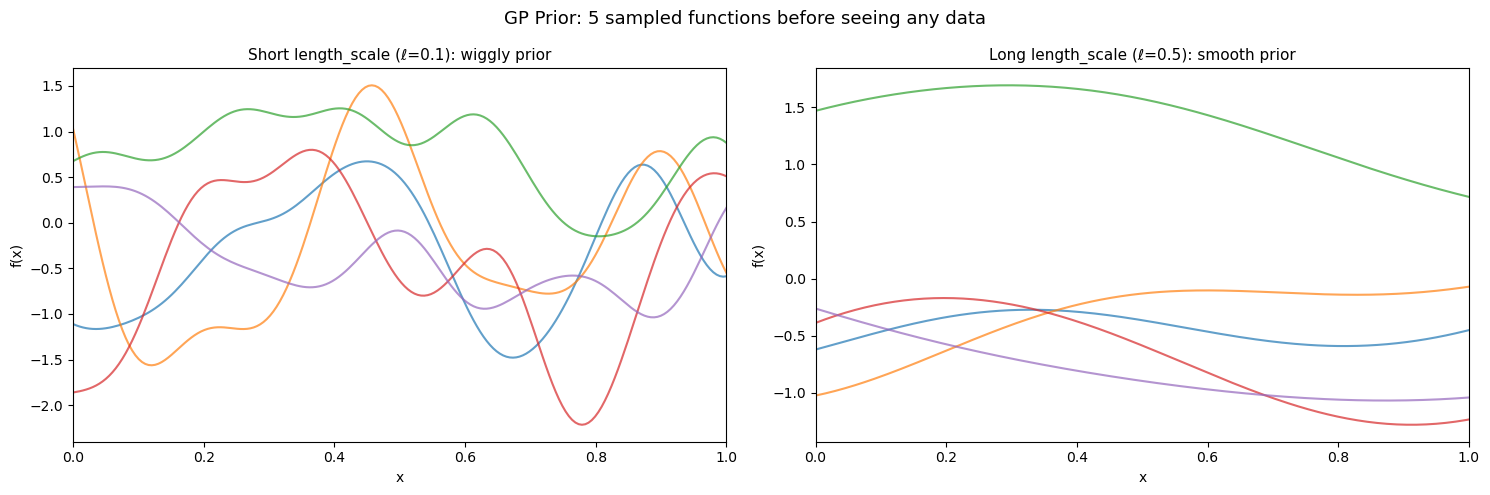


What you see:
  • Each coloured line is one POSSIBLE function the GP believes in.
  • With ℓ=0.1: many wiggles — the GP allows rapid changes.
  • With ℓ=0.5: gentle curves — the GP believes the function is smooth.
  • NONE of these is 'the' function. They're all hypotheses.
  • After seeing data, only hypotheses consistent with observations survive.



In [2]:
"""
SECTION 1.4 — Visualise what a GP Prior looks like before any data.

KEY IDEA: Before observing any data, the GP is just a family of smooth curves.
The length_scale controls how 'wiggly' those curves are.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x_grid = np.linspace(0, 1, 200).reshape(-1, 1)

for ax, length_scale, title in zip(
    axes,
    [0.1, 0.5],
    ["Short length_scale (ℓ=0.1): wiggly prior",
     "Long length_scale (ℓ=0.5): smooth prior"]
):
    # ── THEORY CONNECTION ────────────────────────────────────────────────
    # RBF(length_scale=ℓ) defines k(x,x') = exp(-||x-x'||² / 2ℓ²)
    # 'length_scale_bounds="fixed"' means we won't optimise ℓ during fit —
    # we trust our choice (important for Bayesian Optimisation).
    # ────────────────────────────────────────────────────────────────────
    kernel = RBF(length_scale=length_scale, length_scale_bounds='fixed')
    
    # An unfitted GP represents the PRIOR — all functions equally plausible
    gp = GaussianProcessRegressor(kernel=kernel)
    
    # Sample 5 random functions from the prior
    # random_state fixes the seed so samples are reproducible
    prior_samples = gp.sample_y(x_grid, n_samples=5, random_state=42)
    
    for sample in prior_samples.T:
        ax.plot(x_grid, sample, alpha=0.7)
    
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_xlim(0, 1)

fig.suptitle('GP Prior: 5 sampled functions before seeing any data', fontsize=13)
plt.tight_layout()
plt.show()

print("""
What you see:
  • Each coloured line is one POSSIBLE function the GP believes in.
  • With ℓ=0.1: many wiggles — the GP allows rapid changes.
  • With ℓ=0.5: gentle curves — the GP believes the function is smooth.
  • NONE of these is 'the' function. They're all hypotheses.
  • After seeing data, only hypotheses consistent with observations survive.
""")

## 1.5 The GP Posterior: Updating Beliefs with Data

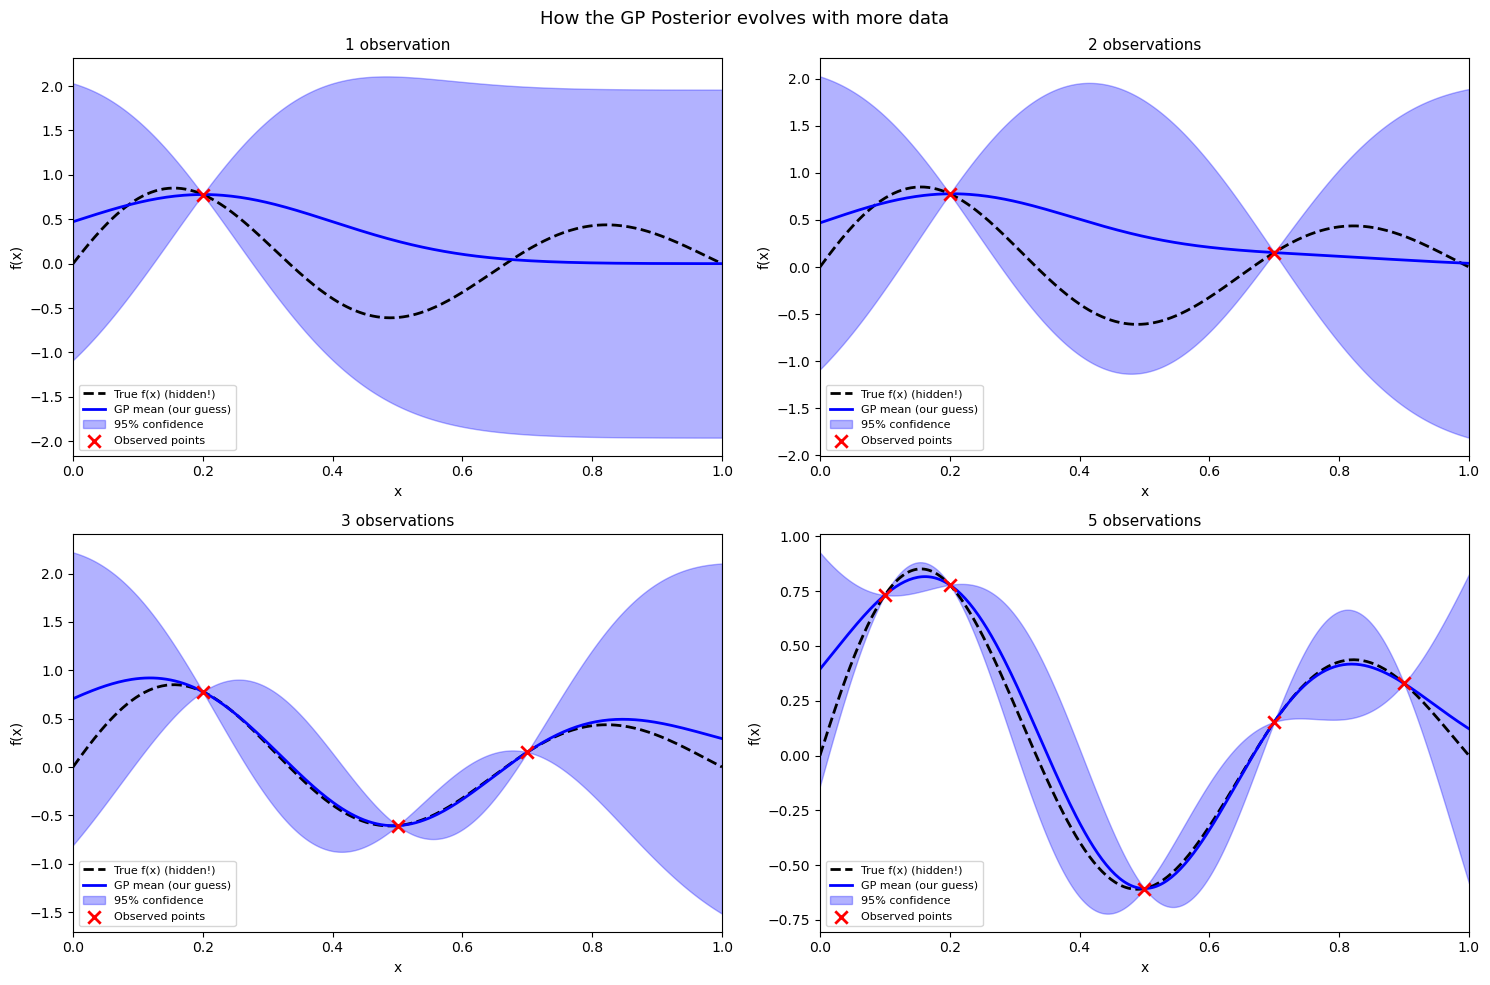


What you see:
  • Blue line  = GP mean  → our BEST GUESS of where f(x) lies
  • Blue band  = uncertainty → where we are NOT confident
  • Red X's    = observed data points
  • Black dashed = the real function (we normally don't know this!)

Notice:
  1. At observed points, the band COLLAPSES to zero width — we are certain!
  2. Far from observations, the band is WIDE — we are uncertain.
  3. More observations → the GP guesses the truth more accurately.

  *** This uncertainty is the core of Bayesian Optimisation! ***
  We EXPLOIT high-mean regions and EXPLORE high-uncertainty regions.



In [3]:
"""
SECTION 1.5 — Watch the GP update its beliefs as we add data.

KEY IDEAS demonstrated:
  • posterior_mean  = our best estimate of f(x)
  • posterior_std   = our UNCERTAINTY at each x
  • Near observed points: std → 0 (we are certain!)
  • Far from observations: std stays large (we are uncertain)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# A simple 1D black-box function to illustrate
def toy_function(x):
    """The 'truth' — normally we can't evaluate this directly."""
    return np.sin(3 * np.pi * x) * np.exp(-x)

x_grid = np.linspace(0, 1, 300).reshape(-1, 1)
y_true = toy_function(x_grid.ravel())

# Progressively add observations
observation_sets = [
    (np.array([[0.2]]),                  "1 observation"),
    (np.array([[0.2], [0.7]]),           "2 observations"),
    (np.array([[0.2], [0.5], [0.7]]),    "3 observations"),
    (np.array([[0.1], [0.2], [0.5], [0.7], [0.9]]),  "5 observations"),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

# ── THEORY CONNECTION ────────────────────────────────────────────────────
# alpha=1e-10 is the noise level σ² added to the diagonal of k(X,X).
# Very small → we trust our observations exactly (noiseless observations).
# Larger values → observations have noise, GP won't fit exactly through them.
# ────────────────────────────────────────────────────────────────────────
kernel = RBF(length_scale=0.2, length_scale_bounds='fixed')

for ax, (X_obs, title) in zip(axes, observation_sets):
    y_obs = toy_function(X_obs.ravel())
    
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
    gp.fit(X_obs, y_obs)  # ← This computes the POSTERIOR
    
    # predict returns:
    #   post_mean  → μ*(X*) from the formula above
    #   post_std   → diagonal of √Σ*(X*)  (std dev, not variance)
    post_mean, post_std = gp.predict(x_grid, return_std=True)
    
    ax.plot(x_grid, y_true, 'k--', lw=2, label='True f(x) (hidden!)')
    ax.plot(x_grid, post_mean, 'b-', lw=2, label='GP mean (our guess)')
    
    # fill_between draws the UNCERTAINTY BAND: mean ± 1.96 × std
    # This is the 95% confidence interval under the Gaussian assumption
    ax.fill_between(
        x_grid.ravel(),
        post_mean - 1.96 * post_std,
        post_mean + 1.96 * post_std,
        alpha=0.3, color='blue', label='95% confidence'
    )
    
    ax.scatter(X_obs, y_obs, c='red', zorder=5, s=80,
               marker='x', linewidth=2, label='Observed points')
    
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)

fig.suptitle('How the GP Posterior evolves with more data', fontsize=13)
plt.tight_layout()
plt.show()

print("""
What you see:
  • Blue line  = GP mean  → our BEST GUESS of where f(x) lies
  • Blue band  = uncertainty → where we are NOT confident
  • Red X's    = observed data points
  • Black dashed = the real function (we normally don't know this!)

Notice:
  1. At observed points, the band COLLAPSES to zero width — we are certain!
  2. Far from observations, the band is WIDE — we are uncertain.
  3. More observations → the GP guesses the truth more accurately.

  *** This uncertainty is the core of Bayesian Optimisation! ***
  We EXPLOIT high-mean regions and EXPLORE high-uncertainty regions.
""")

---

# PART 2: Bayesian Optimisation — The Big Picture

## 2.1 The Problem

We have a **black-box function** `f(x)` that:
- We **cannot see** its mathematical form
- Is **expensive to evaluate** (each query costs time/money)
- We want to find its **maximum**

## 2.2 The Strategy

```
Step 1: Start with initial data → fit a GP (surrogate model)
Step 2: Use an ACQUISITION FUNCTION to choose the BEST next point to query
Step 3: Evaluate f at that point, add to data
Step 4: Refit GP with new data
Step 5: Repeat until budget exhausted
```

The **acquisition function** encodes our strategy. It answers:  
*"Given what I know (GP posterior), where should I look next?"*

## 2.3 The Explore-Exploit Dilemma

This is the central tension in optimisation:

| Strategy | Focus | Risk |
|----------|-------|------|
| **Exploit** | Query where GP mean is highest | Miss the true maximum elsewhere |
| **Explore** | Query where uncertainty is highest | Waste queries in unimportant regions |
| **Balance** | Trade off both | The "right" balance depends on the problem |

We study 3 acquisition functions, each with a different philosophy.

---

# PART 3: UCB — Upper Confidence Bound

## 3.1 The Intuition

**UCB** is the most intuitive acquisition function. It says:

> *"Be optimistic! When uncertain, assume things MIGHT be great."*

At each point x, we compute:
$$\text{UCB}(x) = \underbrace{\mu(x)}_{\text{exploitation}} + \beta \cdot \underbrace{\sigma(x)}_{\text{exploration}}$$

Where:
- `μ(x)` = posterior mean (what we expect)
- `σ(x)` = posterior std deviation (our uncertainty)
- `β` = **exploration-exploitation trade-off parameter**

## 3.2 Understanding β

```
β = 0:   UCB = μ(x)  → Pure exploitation (greedy, may miss global max)
β = ∞:   UCB ≈ σ(x)  → Pure exploration (random-like, very slow)
β = 1.96: A common choice — gives 95% confidence upper bound
```

**Visual analogy:**
```
Region A: mean=1.0, std=0.1  →  UCB ≈ 1.0 + 1.96×0.1 = 1.196   (probably good)
Region B: mean=0.5, std=0.5  →  UCB ≈ 0.5 + 1.96×0.5 = 1.480   (uncertain but possibly better!)
Region C: mean=0.2, std=1.0  →  UCB ≈ 0.2 + 1.96×1.0 = 2.160   (very uncertain, chosen!)
```

UCB picks **Region C** — it might be bad, but it *could* be amazing.

## 3.3 🐍 Python Code → Theory Connection

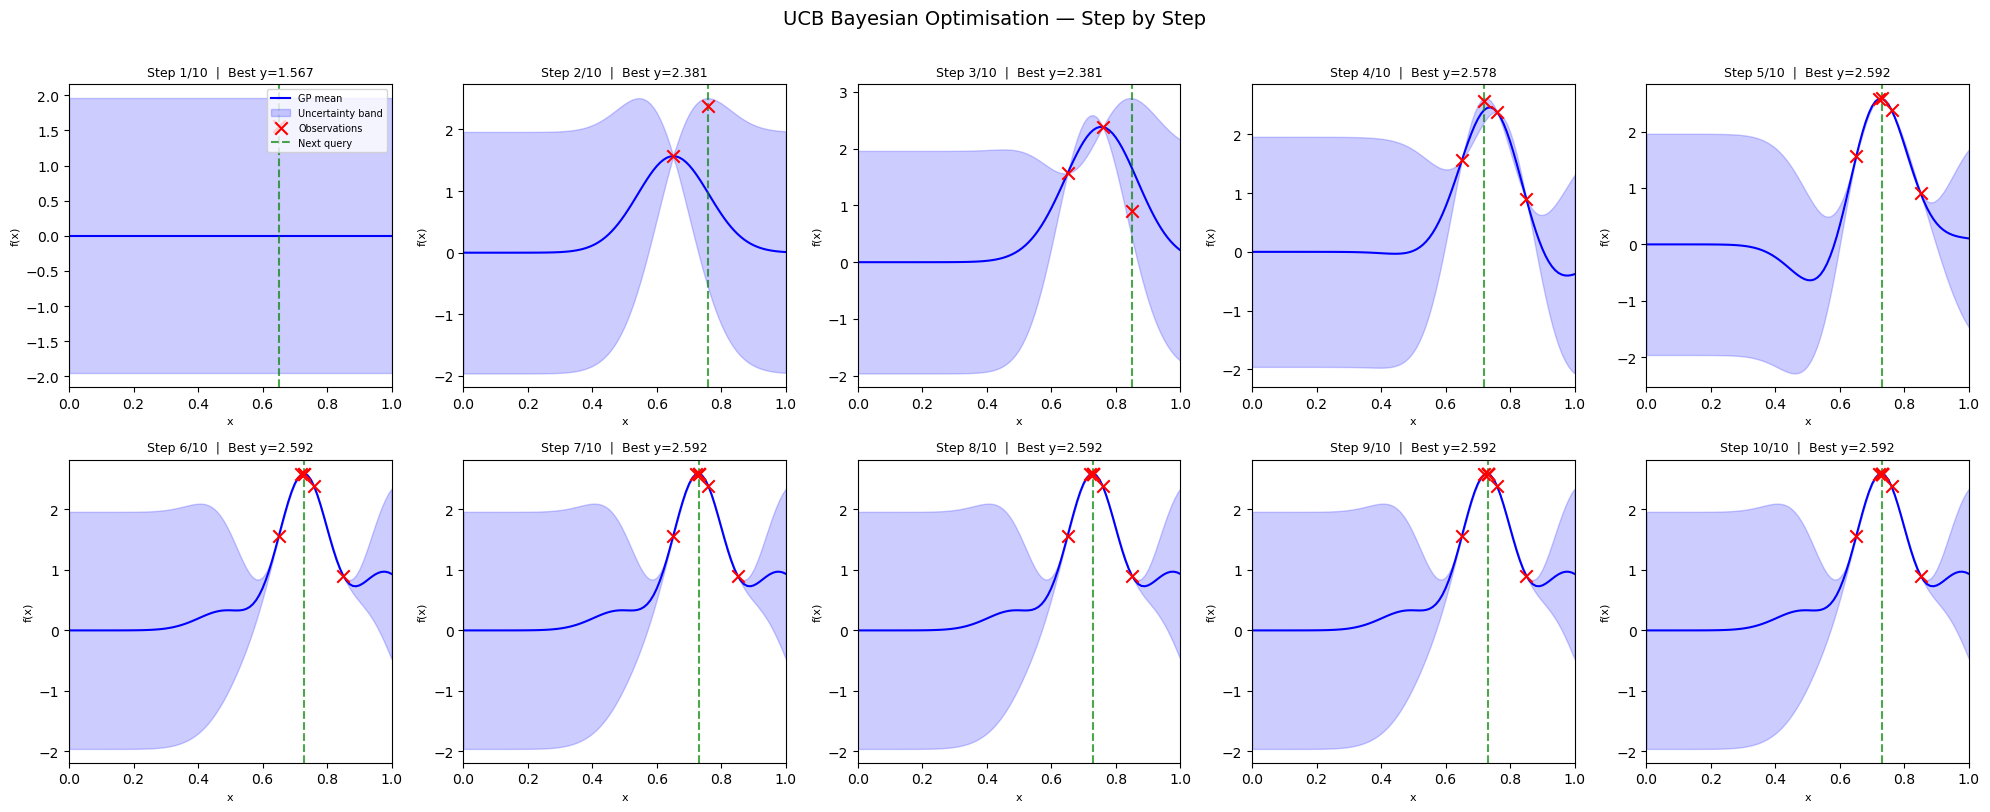

True Maximum (grid search): 2.5931
Best Observed (UCB):        2.5924
Difference:                 0.0008

KEY OBSERVATIONS:
  1. Early steps: UCB explores areas where the band is WIDE (high σ).
  2. Middle steps: Once a promising region is found, it exploits.
  3. Later steps: The band narrows around the maximum.
  4. UCB tends to be EXPLORATORY — it tries many regions.

  NOTE on the acquisition formula:
    acquisition = post_mean + beta * post_std
    ↑ exploitation      ↑ exploration



In [4]:
"""
SECTION 3.3 — UCB on function_1 from the black-box challenge.

UCB formula:  acquisition(x) = mean(x) + β × std(x)

We trace every line back to the math above.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# ════════════════════════════════════════════════════════════════
# STEP 0: Load black-box data (function_1 has 10 points in 2D)
# ════════════════════════════════════════════════════════════════
# NOTE: if you ran the data-loading cell above, 'data' is already available.
# Otherwise, load it again here by re-running PART 0.
# For this demo we'll simulate a simple 1D toy to illustrate the algorithm.

# ════════════════════════════════════════════════════════════════
# HYPERPARAMETERS — and WHY each one exists
# ════════════════════════════════════════════════════════════════

# Length scale: controls smoothness of the GP (see Part 1.4)
rbf_lengthscale = 0.11

# Noise: how much we trust each observation
# 1e-10 ≈ 0 → we trust observations perfectly (noiseless black box)
noise_assumption = 1e-10

# β: the exploration-exploitation trade-off
# β=1.96 → upper 97.5th percentile of the Gaussian (95% confidence)
beta = 1.96

# ════════════════════════════════════════════════════════════════
# STEP 1: Build the kernel
# RBF with FIXED bounds = we won't let sklearn auto-optimise ℓ
# This is intentional: in BO we set ℓ by domain knowledge
# ════════════════════════════════════════════════════════════════
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')

# ════════════════════════════════════════════════════════════════
# STEP 2: Simulate a toy 1D black-box function
# (In the real challenge, you'd call the actual oracle instead)
# ════════════════════════════════════════════════════════════════
np.random.seed(42)
modes = np.random.randint(1, 4)
means = np.random.uniform(0.1, 0.9, size=modes)
stds  = np.random.uniform(0.005, 0.03, size=modes)
amps  = np.random.uniform(1, 2, size=modes)

def black_box_1d(x):
    """Our toy black-box (normally hidden from the optimiser!)."""
    exp = -(x - means)**2 / stds
    return np.sum(amps * np.exp(exp))

# ════════════════════════════════════════════════════════════════
# STEP 3: Initialise with one random point
# ════════════════════════════════════════════════════════════════
X_obs = []   # Observed x values
Y_obs = []   # Observed f(x) values
best_y = -np.inf

# Evaluation grid — we'll evaluate the acquisition at 101 candidate points
x_grid = np.linspace(0, 1, 101).reshape(-1, 1)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

N_ITERATIONS = 10

for i in range(N_ITERATIONS):
    ax = axes[i]
    
    # ── THEORY: Build the GP Surrogate Model ─────────────────────────────
    # The GP is our SURROGATE — it approximates f(x) using observed data.
    # alpha = σ² noise term (see posterior mean formula in Part 1.2)
    # ────────────────────────────────────────────────────────────────────
    gp = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
    
    if i == 0:
        # No data yet: GP is just the PRIOR
        # predict on unfitted GP returns zeros and ones
        post_mean = np.zeros(len(x_grid))
        post_std  = np.ones(len(x_grid))
    else:
        # FIT: Compute posterior given observed data
        # Internally: inverts [k(X,X) + σ²I] and stores it
        gp.fit(np.array(X_obs).reshape(-1, 1), np.array(Y_obs))
        
        # PREDICT: Return μ*(x_grid) and σ*(x_grid)
        # return_std=True → returns σ (not σ²)
        post_mean, post_std = gp.predict(x_grid, return_std=True)
        post_mean = post_mean.squeeze()
    
    # ── THEORY: Compute UCB Acquisition Function ──────────────────────
    # UCB(x) = μ(x) + β·σ(x)
    # This is the UPPER part of the confidence interval
    # Maximising UCB = "be optimistic in the face of uncertainty"
    # ────────────────────────────────────────────────────────────────────
    acquisition = post_mean + beta * post_std
    
    # ── THEORY: Select next query point ───────────────────────────────
    # x* = argmax UCB(x) over candidate points
    # First iteration: random (no prior knowledge)
    # ────────────────────────────────────────────────────────────────────
    if i == 0:
        x_next = np.random.uniform(0, 1)
    else:
        x_next = x_grid.ravel()[np.argmax(acquisition)]
    
    # ── EVALUATE the black-box (the expensive step!) ─────────────────
    y_next = black_box_1d(x_next)
    X_obs.append(x_next)
    Y_obs.append(y_next)
    best_y = max(best_y, y_next)
    
    # ── Plot ─────────────────────────────────────────────────────────
    ax.plot(x_grid, post_mean, 'b-', lw=1.5, label='GP mean')
    ax.fill_between(x_grid.ravel(),
                    post_mean - beta * post_std,
                    post_mean + beta * post_std,
                    alpha=0.2, color='blue', label='Uncertainty band')
    ax.scatter(X_obs, Y_obs, c='red', marker='x', s=80, zorder=5, label='Observations')
    
    # Mark the acquisition maximum (where we JUST queried)
    ax.axvline(x=x_next, color='green', linestyle='--', alpha=0.7, label='Next query')
    
    ax.set_title(f'Step {i+1}/10  |  Best y={best_y:.3f}', fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_xlabel('x', fontsize=8)
    ax.set_ylabel('f(x)', fontsize=8)

# Show legend on first subplot only
axes[0].legend(fontsize=7, loc='upper right')

fig.suptitle('UCB Bayesian Optimisation — Step by Step', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Final evaluation
x_fine = np.linspace(0, 1, 1000)
y_true_all = np.array([black_box_1d(x) for x in x_fine])
print(f"True Maximum (grid search): {max(y_true_all):.4f}")
print(f"Best Observed (UCB):        {best_y:.4f}")
print(f"Difference:                 {abs(max(y_true_all) - best_y):.4f}")

print("""
KEY OBSERVATIONS:
  1. Early steps: UCB explores areas where the band is WIDE (high σ).
  2. Middle steps: Once a promising region is found, it exploits.
  3. Later steps: The band narrows around the maximum.
  4. UCB tends to be EXPLORATORY — it tries many regions.

  NOTE on the acquisition formula:
    acquisition = post_mean + beta * post_std
    ↑ exploitation      ↑ exploration
""")

---

# PART 4: Variance — Pure Exploration

## 4.1 The Intuition

**Variance sampling** ignores the mean entirely and focuses ONLY on uncertainty:

> *"I don't know what's there — so let's go look!"*

$$\text{Acquisition}(x) = \sigma^2(x)$$

or equivalently (taking the argmax gives the same result):

$$\text{Acquisition}(x) = \sigma(x)$$

## 4.2 When is this Useful?

Variance sampling is useful when:
- You want to **understand the function everywhere** (like building a map)
- You have **no idea where the maximum might be**
- You want to **avoid getting stuck** in a local region

## 4.3 The Downside

It completely **ignores** what we've learned about where the function is likely to be high.  
This can waste queries in regions where f(x) is clearly low.

## 4.4 🐍 Python Code → Theory Connection

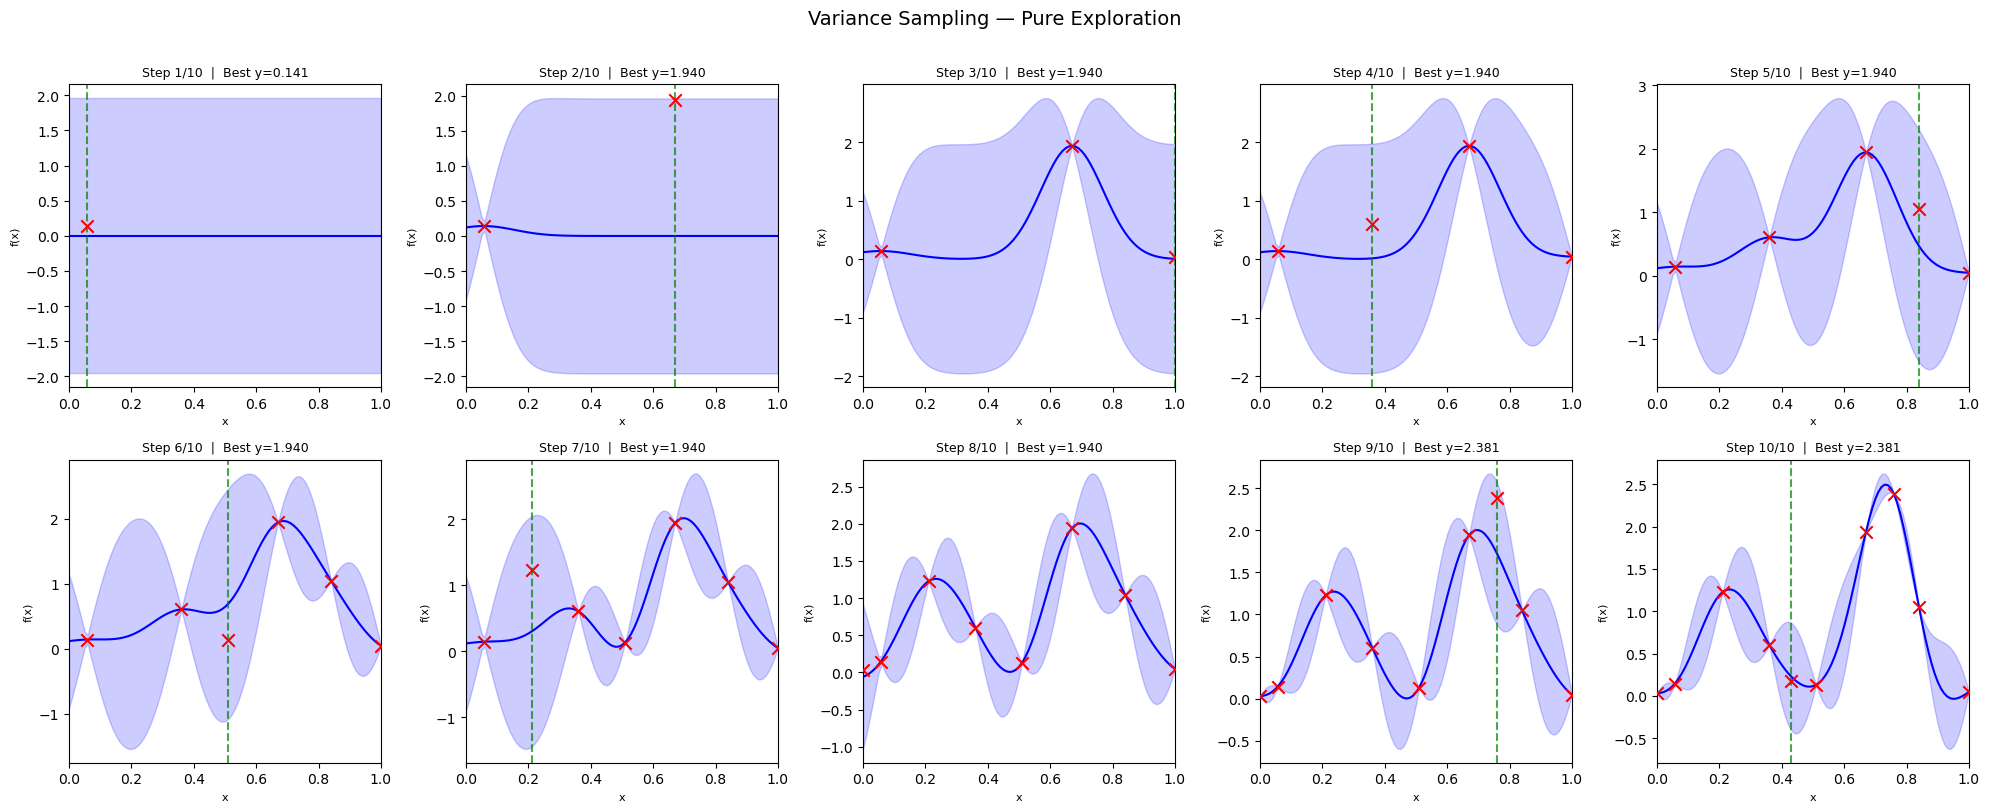

True Maximum (grid search): 2.5931
Best Observed (Variance):   2.3810
Difference:                 0.2121

KEY OBSERVATIONS:
  1. Variance sampling fills the space EVENLY — it explores systematically.
  2. It does NOT rush to the highest region — it visits everywhere.
  3. After N steps, it typically has evenly spaced observations.

  COMPARISON to UCB:
    UCB = mean + β·std  → guided by BOTH mean and uncertainty
    Var = std²           → guided by uncertainty ALONE

  Use Variance when you want a 'map' of the function,
  not necessarily the fastest path to the maximum.



In [5]:
"""
SECTION 4.4 — Variance Sampling: Pure Exploration.

Acquisition formula: acquisition(x) = post_std² = post_std ** 2

Compare with UCB:    acquisition(x) = post_mean + β × post_std
The KEY DIFFERENCE:  Variance ignores post_mean entirely!
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# Same hyperparameters as before
rbf_lengthscale = 0.1
noise_assumption = 1e-10
beta = 1.96

kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')

# Use the SAME black-box for fair comparison
X_obs = []
Y_obs = []
best_y = -np.inf
x_grid = np.linspace(0, 1, 101).reshape(-1, 1)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i in range(10):
    ax = axes[i]
    
    gp = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
    
    if i == 0:
        post_mean = np.zeros(len(x_grid))
        post_std  = np.ones(len(x_grid))
    else:
        gp.fit(np.array(X_obs).reshape(-1, 1), np.array(Y_obs))
        post_mean, post_std = gp.predict(x_grid, return_std=True)
        post_mean = post_mean.squeeze()
    
    # ── THEORY: Variance Acquisition ─────────────────────────────────
    # acquisition(x) = σ²(x) = post_std²
    # This is the POSTERIOR VARIANCE — our squared uncertainty.
    # We go to wherever we are MOST uncertain, ignoring the mean.
    # ────────────────────────────────────────────────────────────────
    acquisition = post_std ** 2     # ← THE ONLY DIFFERENCE from UCB!
    
    if i == 0:
        x_next = np.random.uniform(0, 1)
    else:
        x_next = x_grid.ravel()[np.argmax(acquisition)]
    
    y_next = black_box_1d(x_next)
    X_obs.append(x_next)
    Y_obs.append(y_next)
    best_y = max(best_y, y_next)
    
    ax.plot(x_grid, post_mean, 'b-', lw=1.5, label='GP mean')
    ax.fill_between(x_grid.ravel(),
                    post_mean - beta * post_std,
                    post_mean + beta * post_std,
                    alpha=0.2, color='blue')
    ax.scatter(X_obs, Y_obs, c='red', marker='x', s=80, zorder=5)
    ax.axvline(x=x_next, color='green', linestyle='--', alpha=0.7)
    
    ax.set_title(f'Step {i+1}/10  |  Best y={best_y:.3f}', fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_xlabel('x', fontsize=8)
    ax.set_ylabel('f(x)', fontsize=8)

fig.suptitle('Variance Sampling — Pure Exploration', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

x_fine = np.linspace(0, 1, 1000)
y_true_all = np.array([black_box_1d(x) for x in x_fine])
print(f"True Maximum (grid search): {max(y_true_all):.4f}")
print(f"Best Observed (Variance):   {best_y:.4f}")
print(f"Difference:                 {abs(max(y_true_all) - best_y):.4f}")

print("""
KEY OBSERVATIONS:
  1. Variance sampling fills the space EVENLY — it explores systematically.
  2. It does NOT rush to the highest region — it visits everywhere.
  3. After N steps, it typically has evenly spaced observations.

  COMPARISON to UCB:
    UCB = mean + β·std  → guided by BOTH mean and uncertainty
    Var = std²           → guided by uncertainty ALONE

  Use Variance when you want a 'map' of the function,
  not necessarily the fastest path to the maximum.
""")

---

# PART 5: PI — Probability of Improvement

## 5.1 The Intuition

**PI** asks a very specific question at each candidate point x:

> *"What is the PROBABILITY that querying here will beat my current best?"*

$$\text{PI}(x) = P\left(f(x) > y^*_{\text{max}} + \eta\right) = \Phi\!\left(\frac{\mu(x) - y^*_{\text{max}} - \eta}{\sigma(x)}\right)$$

Where:
- `Φ` = CDF of the standard normal distribution (`scipy.stats.norm.cdf`)
- `y*_max` = current best observed value
- `η` (eta) = a small threshold — we require a **meaningful** improvement

## 5.2 Understanding η

η is a critical parameter:

```
η = 0:     Any improvement counts → exploitative (risky: may get stuck)
η = 0.01:  Require ≥1% improvement above current best → more exploratory
η = large: Require huge improvement → very exploratory (like variance)
```

## 5.3 The z-score Interpretation

The term inside Φ is a **z-score**:
$$z = \frac{\mu(x) - y^*_{\text{max}} - \eta}{\sigma(x)}$$

- **z >> 0**: The mean is well above current best → high probability of improvement
- **z = 0**: 50% chance of improvement (breakeven)
- **z << 0**: Unlikely to improve → avoid

## 5.4 How PI Balances Exploration and Exploitation

PI naturally balances:
- **Exploitation**: High mean → high z → high PI
- **Exploration**: High std (large denominator) → even distant regions can have high z

## 5.5 🐍 Python Code → Theory Connection

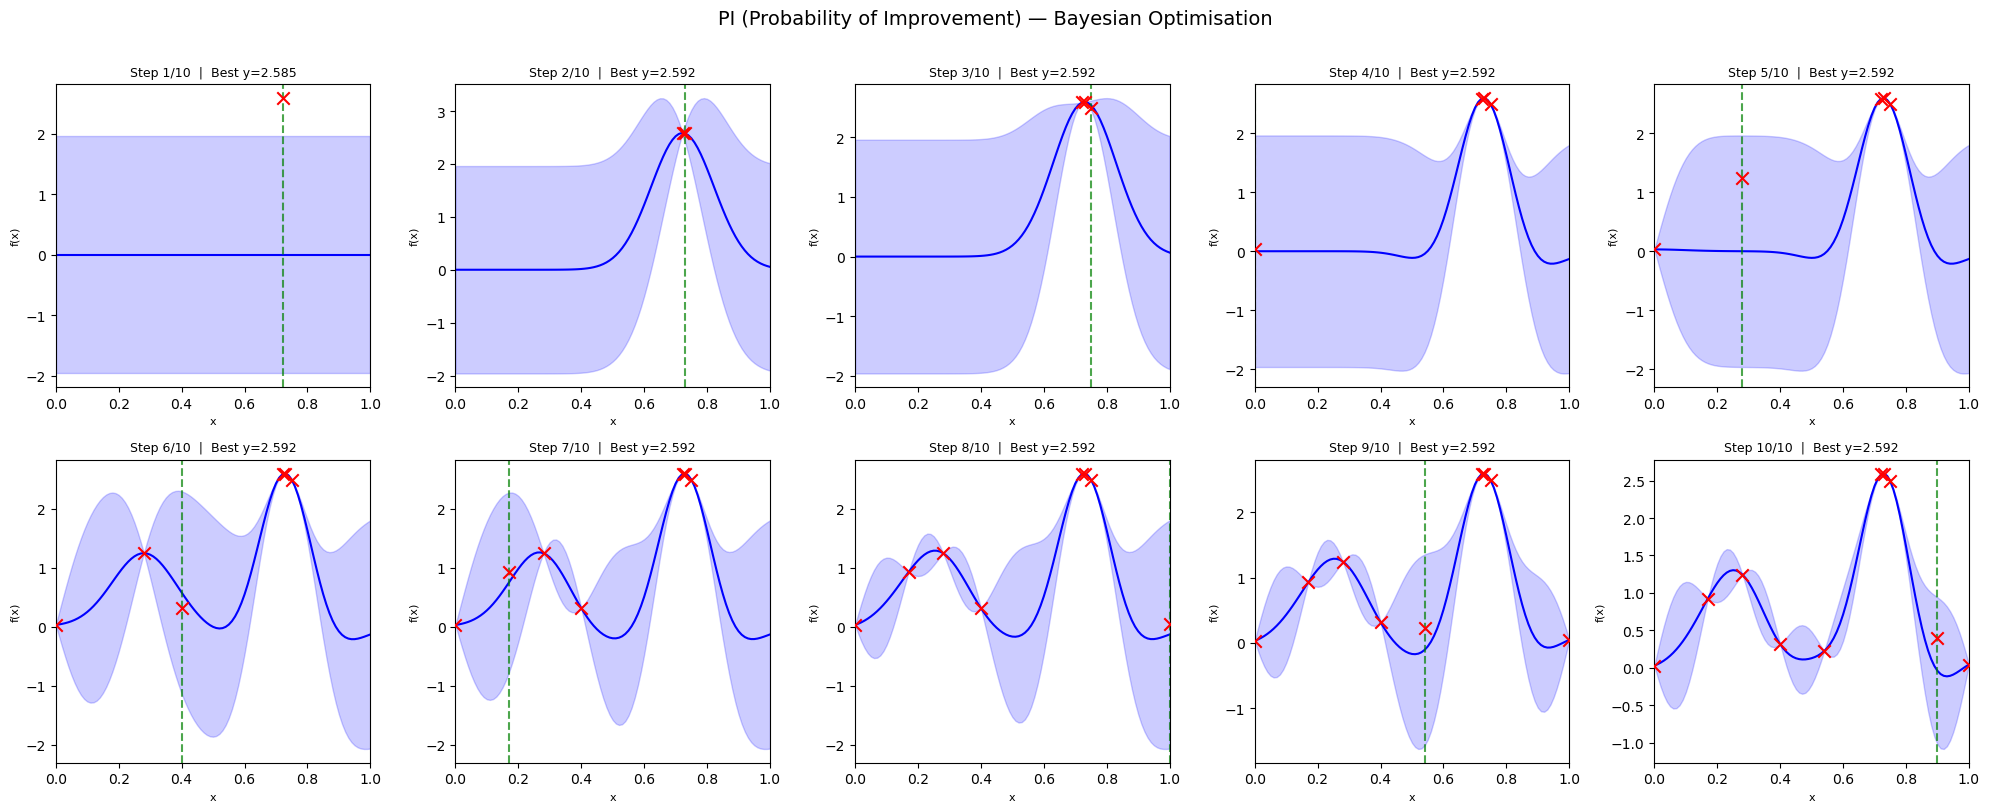

True Maximum (grid search): 2.5931
Best Observed (PI):         2.5924
Difference:                 0.0008

KEY OBSERVATIONS:
  1. PI focuses on the 'frontiers' — points just outside known high regions.
  2. eta > 0 prevents it from querying the SAME point repeatedly.
  3. PI can get 'greedy' and exploit too quickly (especially with eta=0).

  z-score walkthrough:
    If mean=1.5, y_max=1.4, eta=0.01, std=0.2:
    z = (1.5 - 1.4 - 0.01) / 0.2 = 0.09 / 0.2 = 0.45
    PI = Φ(0.45) ≈ 0.67  →  67% chance of improvement!

    If instead mean=0.5 (far from maximum), std=0.8:
    z = (0.5 - 1.4 - 0.01) / 0.8 = -0.91 / 0.8 = -1.14
    PI = Φ(-1.14) ≈ 0.13  →  only 13% chance of improvement.



In [6]:
"""
SECTION 5.5 — Probability of Improvement (PI).

PI formula:
  z           = (post_mean - y_max - eta) / (post_std + epsilon)
  acquisition = norm.cdf(z)

The epsilon (1e-12) avoids division by zero when post_std ≈ 0
(which happens AT observed points, where the GP is certain).
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm     # ← provides Φ (CDF of standard normal)

# Hyperparameters
rbf_lengthscale = 0.1
noise_assumption = 1e-10
beta = 1.96
eta = 0.01    # ← require at least 1% improvement above current best

kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')

X_obs = []
Y_obs = []
best_y = -np.inf
x_grid = np.linspace(0, 1, 101).reshape(-1, 1)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i in range(10):
    ax = axes[i]
    
    gp = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
    
    if i == 0:
        post_mean = np.zeros(len(x_grid))
        post_std  = np.ones(len(x_grid))
    else:
        gp.fit(np.array(X_obs).reshape(-1, 1), np.array(Y_obs))
        post_mean, post_std = gp.predict(x_grid, return_std=True)
        post_mean = post_mean.squeeze()
    
    # ── THEORY: PI Acquisition ────────────────────────────────────────
    # Step 1: Compute z-score for improvement
    #   z = (how far mean is above threshold) / (uncertainty at this point)
    # Step 2: Apply CDF → probability that a sample from N(mean, std²)
    #         exceeds (y_max + eta)
    # ────────────────────────────────────────────────────────────────
    if i == 0:
        # No current best yet → uniform acquisition
        acquisition = np.ones_like(post_mean)
    else:
        y_max = max(Y_obs)          # current best observed value
        
        # z-score: how many standard deviations above (y_max + eta) is the mean?
        z = (post_mean - y_max - eta) / (post_std + 1e-12)
        
        # norm.cdf(z) = Φ(z) = P(Z ≤ z) where Z~N(0,1)
        # This equals P(f(x) > y_max + eta)
        acquisition = norm.cdf(z)
    
    x_next = np.random.uniform(0, 1) if i == 0 else x_grid.ravel()[np.argmax(acquisition)]
    y_next = black_box_1d(x_next)
    X_obs.append(x_next)
    Y_obs.append(y_next)
    best_y = max(best_y, y_next)
    
    ax.plot(x_grid, post_mean, 'b-', lw=1.5)
    ax.fill_between(x_grid.ravel(),
                    post_mean - beta * post_std,
                    post_mean + beta * post_std,
                    alpha=0.2, color='blue')
    ax.scatter(X_obs, Y_obs, c='red', marker='x', s=80, zorder=5)
    ax.axvline(x=x_next, color='green', linestyle='--', alpha=0.7)
    
    ax.set_title(f'Step {i+1}/10  |  Best y={best_y:.3f}', fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_xlabel('x', fontsize=8)
    ax.set_ylabel('f(x)', fontsize=8)

fig.suptitle('PI (Probability of Improvement) — Bayesian Optimisation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

x_fine = np.linspace(0, 1, 1000)
y_true_all = np.array([black_box_1d(x) for x in x_fine])
print(f"True Maximum (grid search): {max(y_true_all):.4f}")
print(f"Best Observed (PI):         {best_y:.4f}")
print(f"Difference:                 {abs(max(y_true_all) - best_y):.4f}")

print("""
KEY OBSERVATIONS:
  1. PI focuses on the 'frontiers' — points just outside known high regions.
  2. eta > 0 prevents it from querying the SAME point repeatedly.
  3. PI can get 'greedy' and exploit too quickly (especially with eta=0).

  z-score walkthrough:
    If mean=1.5, y_max=1.4, eta=0.01, std=0.2:
    z = (1.5 - 1.4 - 0.01) / 0.2 = 0.09 / 0.2 = 0.45
    PI = Φ(0.45) ≈ 0.67  →  67% chance of improvement!

    If instead mean=0.5 (far from maximum), std=0.8:
    z = (0.5 - 1.4 - 0.01) / 0.8 = -0.91 / 0.8 = -1.14
    PI = Φ(-1.14) ≈ 0.13  →  only 13% chance of improvement.
""")

---

# PART 6: Side-by-Side Comparison

## 6.1 Acquisition Function Summary

| | UCB | Variance | PI |
|---|---|---|---|
| **Formula** | μ + β·σ | σ² | Φ((μ - y_max - η) / σ) |
| **Exploitation** | ✓✓ | ✗ | ✓ |
| **Exploration** | ✓ | ✓✓ | ✓ |
| **Key parameter** | β | — | η |
| **Strengths** | Simple, tuneable | Systematic exploration | Principled improvement criterion |
| **Weaknesses** | Can over-explore | Ignores function values | Can get stuck exploiting |

## 6.2 🐍 Run All Three on the Same Problem

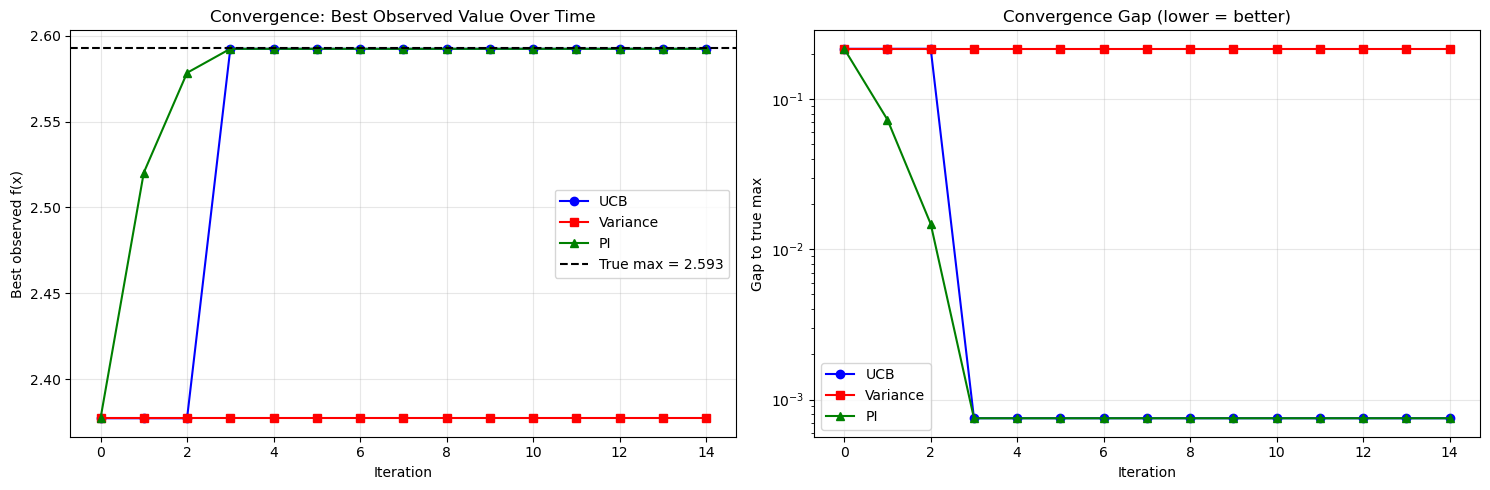

After 15 queries:
  True maximum:  2.5931
  UCB best:      2.5924  (gap = 0.0008)
  Variance best: 2.3773  (gap = 0.2158)
  PI best:       2.5924  (gap = 0.0008)

INTERPRETATION:
  On simple 1D problems, all three methods can work well.
  Differences emerge on higher-dimensional, multi-modal problems.

  Rule of thumb:
    • UCB: Good general-purpose choice, interpretable β parameter
    • Variance: Good for initial exploration / when you have no clue
    • PI: Good when you want principled 'probability of beating the best'



In [7]:
"""
SECTION 6.2 — Compare UCB, Variance, and PI on the same black-box.

This cell runs all three algorithms with the SAME random seed
and compares their convergence.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm

np.random.seed(123)  # fixed seed for fair comparison

# Shared settings
kernel       = RBF(length_scale=0.11, length_scale_bounds='fixed')
noise        = 1e-10
beta         = 1.96
eta          = 0.01
N_ITER       = 15
x_grid       = np.linspace(0, 1, 101).reshape(-1, 1)
x_fine       = np.linspace(0, 1, 1000)
y_true_all   = np.array([black_box_1d(x) for x in x_fine])
y_true_max   = max(y_true_all)

# First random point is SHARED
x_init = np.random.uniform(0, 1)
y_init = black_box_1d(x_init)

def run_bo(acquisition_name, n_iter=N_ITER):
    X_obs = [x_init]
    Y_obs = [y_init]
    bests = [y_init]
    
    for i in range(1, n_iter):
        gp = GaussianProcessRegressor(kernel=kernel, alpha=noise)
        gp.fit(np.array(X_obs).reshape(-1, 1), np.array(Y_obs))
        post_mean, post_std = gp.predict(x_grid, return_std=True)
        post_mean = post_mean.squeeze()
        
        # Select acquisition function
        if acquisition_name == 'UCB':
            acq = post_mean + beta * post_std
        elif acquisition_name == 'Variance':
            acq = post_std ** 2
        elif acquisition_name == 'PI':
            y_max = max(Y_obs)
            z = (post_mean - y_max - eta) / (post_std + 1e-12)
            acq = norm.cdf(z)
        
        x_next = x_grid.ravel()[np.argmax(acq)]
        y_next = black_box_1d(x_next)
        X_obs.append(x_next)
        Y_obs.append(y_next)
        bests.append(max(bests[-1], y_next))
    
    return X_obs, Y_obs, bests

X_ucb, Y_ucb, best_ucb = run_bo('UCB')
X_var, Y_var, best_var = run_bo('Variance')
X_pi,  Y_pi,  best_pi  = run_bo('PI')

# ── CONVERGENCE PLOT ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(best_ucb, 'b-o', label='UCB')
ax.plot(best_var, 'r-s', label='Variance')
ax.plot(best_pi,  'g-^', label='PI')
ax.axhline(y_true_max, color='black', linestyle='--', label=f'True max = {y_true_max:.3f}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best observed f(x)')
ax.set_title('Convergence: Best Observed Value Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
gap_ucb = [y_true_max - b for b in best_ucb]
gap_var = [y_true_max - b for b in best_var]
gap_pi  = [y_true_max - b for b in best_pi]
ax.plot(gap_ucb, 'b-o', label='UCB')
ax.plot(gap_var, 'r-s', label='Variance')
ax.plot(gap_pi,  'g-^', label='PI')
ax.set_xlabel('Iteration')
ax.set_ylabel('Gap to true max')
ax.set_title('Convergence Gap (lower = better)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print(f"After {N_ITER} queries:")
print(f"  True maximum:  {y_true_max:.4f}")
print(f"  UCB best:      {best_ucb[-1]:.4f}  (gap = {y_true_max - best_ucb[-1]:.4f})")
print(f"  Variance best: {best_var[-1]:.4f}  (gap = {y_true_max - best_var[-1]:.4f})")
print(f"  PI best:       {best_pi[-1]:.4f}  (gap = {y_true_max - best_pi[-1]:.4f})")

print("""
INTERPRETATION:
  On simple 1D problems, all three methods can work well.
  Differences emerge on higher-dimensional, multi-modal problems.

  Rule of thumb:
    • UCB: Good general-purpose choice, interpretable β parameter
    • Variance: Good for initial exploration / when you have no clue
    • PI: Good when you want principled 'probability of beating the best'
""")

---

# PART 7: Applying to the Real Black-Box Challenge

Now we apply what we've learned to the actual multi-dimensional black-box functions.  
This is a template — you'll need to replace `query_oracle(x)` with your actual evaluator.

## 7.1 The Challenge Structure

From the data we loaded:
```
function_1: 10 initial points in 2D
function_2: 10 initial points in 2D
function_3: 15 initial points in 3D
function_4: 30 initial points in 4D
function_5: 20 initial points in 4D
function_6: 20 initial points in 5D
function_7: 30 initial points in 6D
function_8: 40 initial points in 8D
```

Higher dimensions make optimisation **harder** — the search space grows exponentially.

In [8]:
"""
SECTION 7.1 — Template for the Black-Box Challenge.

IMPORTANT: Replace 'simulate_oracle' with your actual oracle function.
           The rest of the code (GP, UCB, etc.) stays exactly the same!
"""

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def simulate_oracle(x_input, function_key):
    """
    PLACEHOLDER: Replace this with your actual black-box evaluator.
    
    In your capstone challenge, this function calls the hidden oracle.
    Here we simulate it using the initial data statistics.
    """
    # Using mean of observed outputs as a placeholder
    # Replace with: return your_actual_oracle_call(x_input)
    return float(np.random.randn())  # placeholder


def run_bo_multi_dim(function_key, acquisition='UCB', n_iter=10, beta=1.96, eta=0.01):
    """
    General-purpose Bayesian Optimisation for multi-dimensional functions.
    
    Parameters
    ----------
    function_key : str
        e.g. 'function_1', 'function_3', ...
    acquisition : str
        'UCB', 'Variance', or 'PI'
    n_iter : int
        Number of additional queries beyond the initial data
    beta : float
        Exploration-exploitation trade-off for UCB
    eta : float
        Improvement threshold for PI
    """
    # ── LOAD INITIAL DATA (from Part 0) ──────────────────────────────────
    X_init = data[function_key]['input']   # shape (n_init, d)
    y_init = data[function_key]['output']  # shape (n_init,)
    d = X_init.shape[1]                    # dimensionality
    n_init = X_init.shape[0]
    
    print(f"\n{'='*60}")
    print(f" Running BO on {function_key} ({d}D)")
    print(f" Acquisition: {acquisition} | Extra iterations: {n_iter}")
    print(f"{'='*60}")
    print(f" Initial data: {n_init} points")
    print(f" Initial best: {max(y_init):.4f}")
    
    # ── BUILD GP SURROGATE ────────────────────────────────────────────────
    # NOTE: For high dimensions, the length scale may need tuning per function.
    # Start with a length_scale in the range 0.1–0.3 for normalised inputs [0,1].
    kernel = RBF(length_scale=0.2, length_scale_bounds='fixed')
    
    X_obs = X_init.copy()
    y_obs = y_init.copy()
    best_so_far = max(y_obs)
    history = [best_so_far]
    
    for step in range(n_iter):
        # ── FIT GP ────────────────────────────────────────────────────────
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
        gp.fit(X_obs, y_obs)
        
        # ── CANDIDATE POINTS (Latin Hypercube or random grid) ─────────────
        # For high-dimensional spaces, we can't enumerate all points.
        # We sample random candidates and pick the best.
        n_candidates = 1000 * d  # more candidates for higher dimensions
        X_cand = np.random.uniform(0, 1, size=(n_candidates, d))
        
        # ── PREDICT mean and std at candidates ────────────────────────────
        mu, sigma = gp.predict(X_cand, return_std=True)
        
        # ── COMPUTE ACQUISITION ───────────────────────────────────────────
        if acquisition == 'UCB':
            acq = mu + beta * sigma
        elif acquisition == 'Variance':
            acq = sigma ** 2
        elif acquisition == 'PI':
            from scipy.stats import norm
            z   = (mu - best_so_far - eta) / (sigma + 1e-12)
            acq = norm.cdf(z)
        
        # ── SELECT NEXT POINT ─────────────────────────────────────────────
        best_idx = np.argmax(acq)
        x_next   = X_cand[best_idx]
        
        # ── QUERY THE ORACLE (EXPENSIVE STEP) ─────────────────────────────
        # 🔴 REPLACE THIS LINE with your actual oracle call:
        y_next = simulate_oracle(x_next, function_key)
        # 🔴 Example: y_next = your_oracle.query(function_key, x_next)
        
        # ── UPDATE DATA ───────────────────────────────────────────────────
        X_obs = np.vstack([X_obs, x_next])
        y_obs = np.append(y_obs, y_next)
        best_so_far = max(best_so_far, y_next)
        history.append(best_so_far)
        
        print(f"  Step {step+1:2d}: x_next={x_next[:2]}... | y={y_next:.4f} | best={best_so_far:.4f}")
    
    print(f"\nFinal best value: {best_so_far:.4f}")
    return history, X_obs, y_obs


# ── Example run on function_1 ────────────────────────────────────────────
# NOTE: This uses a placeholder oracle. Replace with your real one!
if 'function_1' in data:
    history, X_final, y_final = run_bo_multi_dim(
        function_key='function_1',
        acquisition='UCB',
        n_iter=5,
        beta=1.96
    )
else:
    print("Data not loaded — run Part 0 first.")


 Running BO on function_1 (2D)
 Acquisition: UCB | Extra iterations: 5
 Initial data: 10 points
 Initial best: 0.0000
  Step  1: x_next=[0.0020919  0.95248887]... | y=0.0885 | best=0.0885
  Step  2: x_next=[0.98077512 0.01030438]... | y=0.3800 | best=0.3800
  Step  3: x_next=[0.98678577 0.99452638]... | y=0.9402 | best=0.9402
  Step  4: x_next=[0.00335037 0.01266006]... | y=-0.6823 | best=0.9402
  Step  5: x_next=[0.66635068 0.00948495]... | y=0.0077 | best=0.9402

Final best value: 0.9402


---

# PART 8: Summary and Mental Model

## 8.1 The Complete Mental Model

```
                    ┌─────────────────────────────┐
                    │    BLACK BOX FUNCTION        │
                    │  f(x) = ???  (expensive!)    │
                    └──────────────┬──────────────┘
                                   │ query x, get y
                    ┌──────────────▼──────────────┐
                    │    GP SURROGATE MODEL        │
                    │  fit(X_obs, y_obs)           │
                    │  → mean μ(x)  uncertainty σ(x)│
                    └──────────────┬──────────────┘
                                   │ posterior
                    ┌──────────────▼──────────────┐
                    │   ACQUISITION FUNCTION       │
                    │  UCB:   μ + β·σ             │
                    │  Var:   σ²                  │
                    │  PI:    Φ((μ-y_max-η)/σ)   │
                    └──────────────┬──────────────┘
                                   │ argmax → x_next
                    ┌──────────────▼──────────────┐
                    │  QUERY x_next, GET y_next    │
                    │  UPDATE data, REPEAT ────────┘
                    └─────────────────────────────┘
```

## 8.2 Key Equations Reference

| Concept | Equation | Python |
|---------|----------|--------|
| RBF Kernel | $k(x,x') = \exp(-\|x-x'\|^2/2\ell^2)$ | `RBF(length_scale=ℓ)` |
| GP Posterior Mean | $\mu_* = K_{*,X}(K_{X,X}+\sigma^2I)^{-1}y$ | `gp.predict(X_new)[0]` |
| GP Posterior Std | $\sigma_* = \sqrt{K_{*,*} - K_{*,X}(K_{X,X}+\sigma^2I)^{-1}K_{X,*}}$ | `gp.predict(X_new, return_std=True)[1]` |
| UCB | $\mu(x) + \beta\sigma(x)$ | `post_mean + beta * post_std` |
| Variance | $\sigma^2(x)$ | `post_std ** 2` |
| PI | $\Phi\!\left(\frac{\mu(x)-y^*-\eta}{\sigma(x)}\right)$ | `norm.cdf((post_mean - y_max - eta) / post_std)` |

## 8.3 Next Steps for the GitHub Project

This notebook is the **foundation**. Your project can extend it with:

1. **Expected Improvement (EI)** — a more sophisticated version of PI
2. **Multi-restart GP** — trying different length scales and picking the best
3. **Batch BO** — selecting multiple points to query in parallel
4. **Comparison plots** — systematic comparison across all 8 functions
5. **Hyperparameter sensitivity** — how much does β or η matter?

---

> *"Bayesian Optimisation is the art of learning as much as possible from as few experiments as possible."*

In [9]:
"""
FINAL SANITY CHECK — Make sure you understand the code

Fill in the blanks below. Answers are in the comments.
"""

# Q1: What does 'alpha' control in GaussianProcessRegressor(alpha=1e-10)?
# Answer: ________________________________________________________
# (Hint: It's σ² in the posterior mean formula)

# Q2: What does 'return_std=True' return in gp.predict(X, return_std=True)?
# Answer: ________________________________________________________
# (Hint: Is it σ or σ²?)

# Q3: Why do we use 'length_scale_bounds="fixed"' in the kernel?
# Answer: ________________________________________________________
# (Hint: We don't want sklearn to change ℓ during fitting)

# Q4: In UCB, what happens when β → 0?
# Answer: ________________________________________________________
# (Hint: UCB becomes _____ exploitation, _____ exploration)

# Q5: Why do we add 1e-12 to post_std in the PI z-score calculation?
# Answer: ________________________________________________________
# (Hint: What happens at points we've already observed?)

print("Answers:")
print("Q1: 'alpha' is the observation noise variance σ². Small → noiseless observations.")
print("Q2: It returns σ (standard deviation), NOT σ² (variance).")
print("Q3: We fix ℓ to our domain knowledge; unfixing lets sklearn optimise it via MLE.")
print("Q4: β→0 means pure exploitation: UCB = μ (we only go to where mean is highest).")
print("Q5: At observed points, σ≈0, causing division by zero. The 1e-12 prevents this.")

Answers:
Q1: 'alpha' is the observation noise variance σ². Small → noiseless observations.
Q2: It returns σ (standard deviation), NOT σ² (variance).
Q3: We fix ℓ to our domain knowledge; unfixing lets sklearn optimise it via MLE.
Q4: β→0 means pure exploitation: UCB = μ (we only go to where mean is highest).
Q5: At observed points, σ≈0, causing division by zero. The 1e-12 prevents this.
